# Input

In [127]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import plots_dir, base_dir, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.tf_activity.helper import retrieve_feature_data, retrieve_adata_bulk, retrieve_net, calculate_tf_activity, retrieve_sig_stats, get_consensus_net

from ciim.src.clock.helper import clock_save_dir, predict_age, prepare_input
from ciim.src.clock.plots import plot_scatter_age_vs_predictedAge

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' 
tune_model = True
create_smoothed_data = True
temp_dir = f'{save_dir}/temp/'
plt.rcParams["font.family"] = "Arial"
cell_types = ['CD4T', 'CD8T', 'MONO', 'B', 'NK'] # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
n_cell_types = len(cell_types)
train_datasets = ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese', 'data12', 'data13_Korean']
version = 'all_data'

def get_all_predictions(cell_types, evaluate_datasets, version='all_data'):
    obs_store = []

    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs.rename(columns={'disease': 'condition', 'treatment':'condition', 'Max_WHO_Group':'condition'}, inplace=True)
            if 'condition' not in adata.obs.columns:
                adata.obs['condition'] = 'Healthy'
            adata.obs['condition'] = adata.obs['condition'].apply(lambda name: surrogate_names.get(name, name))
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type, version=version)
                obs = adata_c.obs[['age', 'predicted_age', 'sex', 'donor_age']].copy() 
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    return obs

# Calculate feature space using consensus GRNs -> smoothed


In [38]:
if create_smoothed_data:
    from ciim.src.clock.helper import prepare_input
    for feature_type in ['gene_expression']:
        os.makedirs(f'{save_dir}/{feature_type}_smoothed/', exist_ok=True)
        for dataset in datasets_all+datasets_disease+datasets_drug_perturbation:
            for cell_type in cell_types:
                adata = prepare_input(dataset, cell_type, feature_type=feature_type, data_type='bulk')
                adata.obs['donor_age'] = adata.obs['donor_id'].astype(str) + adata.obs['age'].astype(str)
                adata.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')

data1 (976, 1020)
data1 (976, 2050)
data1 (769, 3436)
data1 (973, 1597)
data1 (976, 482)
data7_allTPs_jalil (313, 1022)
data7_allTPs_jalil (313, 2057)
data7_allTPs_jalil (313, 3426)
data7_allTPs_jalil (312, 1590)
data7_allTPs_jalil (313, 485)
data12 (33, 1012)
data12 (33, 2035)
data12 (33, 3398)
data12 (32, 1577)
data12 (33, 483)
SLE_European (150, 1011)
SLE_European (150, 2000)
SLE_European (150, 3409)
SLE_European (148, 1577)
SLE_European (150, 477)
data13_Korean (164, 1023)
data13_Korean (164, 2065)
data13_Korean (164, 3445)
data13_Korean (164, 1600)
data13_Korean (163, 486)
data13_Japanese (148, 1023)
data13_Japanese (147, 2065)
data13_Japanese (147, 3445)
data13_Japanese (145, 1600)
data13_Japanese (147, 486)
SLE_European (150, 1011)
SLE_European (150, 2000)
SLE_European (150, 3409)
SLE_European (148, 1577)
SLE_European (150, 477)
Covid_50MHH (40, 1020)
Covid_50MHH (40, 2051)
Covid_50MHH (40, 3426)
Covid_50MHH (40, 1589)
Covid_50MHH (40, 485)
CXCL9 (77, 1023)
CXCL9 (77, 2065)
CXCL

# Train the model

In [98]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD4T CD8T MONO B NK --datasets_training data1 data7_allTPs_jalil SLE_European data13_Japanese data12 data13_Korean --feature_type gene_expression --data_type bulk --reg_type ridge --version all_data --temp_dir /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/ --age_limit 20 --tune_model
{'cell_types': ['CD4T', 'CD8T', 'MONO', 'B', 'NK'], 'datasets_training': ['data1', 'data7_allTPs_jalil', 'SLE_European', 'data13_Japanese', 'data12', 'data13_Korean'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'all_data', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/', 'age_limit': 20}
building model for cell type: CD4T
(1704, 1002) (1704,)


Best trial: 18. Best value: 0.287801: 100%|██████████| 30/30 [00:03<00:00,  7.51it/s]



 Best alpha: 38.4470, Best CV performance: 0.2878
building model for cell type: CD8T
(1703, 1972) (1703,)


Best trial: 18. Best value: 0.372744: 100%|██████████| 30/30 [00:09<00:00,  3.07it/s]



 Best alpha: 252.5084, Best CV performance: 0.3727
building model for cell type: MONO
(1496, 3356) (1496,)


...


 Best alpha: 4.1361, Best CV performance: -0.9465
building model for cell type: B
(1696, 1555) (1696,)


Best trial: 22. Best value: -0.406247: 100%|██████████| 30/30 [00:09<00:00,  3.02it/s]



 Best alpha: 26.5634, Best CV performance: -0.4062
building model for cell type: NK
(1702, 472) (1702,)


Best trial: 20. Best value: -0.226885: 100%|██████████| 30/30 [00:01<00:00, 22.36it/s]



 Best alpha: 187.2854, Best CV performance: -0.2269


# Cross-validation performance

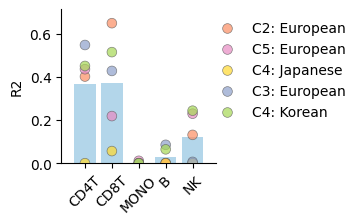

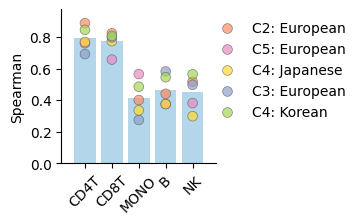

In [40]:
cv_scores_store = []
for cell_type in cell_types:
    scores_df = pd.read_csv(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_cv_scores.csv", 
                            index_col=0)
    mask = scores_df<0
    scores_df[mask] = 0
    scores_df['cell_type'] = cell_type
    cv_scores_store.append(scores_df)
cv_scores = pd.concat(cv_scores_store, axis=0)
# - plot


# Ensure dataset name is a column
cv_scores = cv_scores.reset_index().rename(columns={'index': 'dataset'})

def plot_cv_scores(cv_scores, metric, figsize=[2.5, 2]):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Strip plot (scatter of individual fold scores)
    sns.stripplot(
        data=cv_scores, x='cell_type', y=metric,
        hue='dataset', dodge=False, jitter=False, s=7,
        alpha=0.7, linewidth=0.5, edgecolor='gray', palette=palette_datasets_pretty,
        ax=ax
    )

    # Bar plot (mean scores per cell type)
    sns.barplot(
        data=cv_scores, x='cell_type', y=metric,
        estimator='mean', errorbar=None,
        color=colors_blind[1], alpha=0.5, ax=ax
    )
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
    # Legend
    ax.legend(title='', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # Set axes properties
    ax.set(
        # title=f'{metric.upper()}',
        ylabel=metric.capitalize(),
        xlabel=''
    )
    return fig

figsize=(2, 2)
# Plot R² and Spearman
cv_scores['dataset'] = cv_scores['dataset'].map(surrogate_names)
fig = plot_cv_scores(cv_scores, 'r2', figsize)
fig.savefig(f'{plots_dir}/cv_scores_r2.png', bbox_inches='tight', dpi=300, transparent=True)
fig = plot_cv_scores(cv_scores, 'spearman',figsize)
fig.savefig(f'{plots_dir}/cv_scores_spearman.png', bbox_inches='tight', dpi=300, transparent=True)

In [99]:
# scatter plot
prediction_store = []
for cell_type in cell_types:
    predictions_df = pd.read_csv(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_cv_predictions.csv")
    predictions_df['cell_type'] = cell_type
    prediction_store.append(predictions_df)
prediction_df = pd.concat(prediction_store, axis=0)
prediction_df

,Unnamed: 0,age,predicted_age,dataset,fold,cell_type
0,313,30,17.778466,data7_allTPs_jalil,0,CD4T
1,314,31,22.654669,data7_allTPs_jalil,0,CD4T
2,315,27,34.852108,data7_allTPs_jalil,0,CD4T
3,316,29,42.448745,data7_allTPs_jalil,0,CD4T
4,317,33,31.684786,data7_allTPs_jalil,0,CD4T
...,...,...,...,...,...,...
725,819,49,48.505552,data13_Korean,4,NK
726,821,24,20.855154,data13_Korean,4,NK
727,822,50,40.789276,data13_Korean,4,NK
728,823,26,33.685002,data13_Korean,4,NK


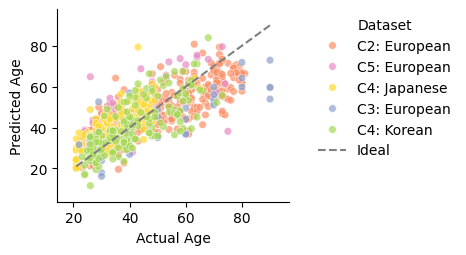

In [104]:
prediction_df['dataset'] = prediction_df['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in ['CD8T']:
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharey=True)

    df = prediction_df[prediction_df['cell_type'] == cell_type]

    plot_scatter_age_vs_predictedAge(df, dataset='', ax=ax, hue='dataset', palette=palette_datasets_pretty, s=30, alpha=0.7)
    ax.legend(loc=(1.1, .2), frameon=False, title='Dataset')
    plt.savefig(f'{plots_dir}/clock_training_datasets.png', bbox_inches='tight', dpi=300, transparent=True)

## Evaluate latent space

In [41]:
from ciim.src.clock.NN.helper import wrapper_get_latent 
cell_type='CD8T'
dataset=datasets_all[1]
adata = retrieve_adata_bulk(dataset=dataset, cell_type=cell_type)
adata = wrapper_get_latent(adata, batch_idx=None, reg_type='NN', cell_type=cell_type, data_type=data_type, feature_type=feature_type, version=version)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//clock/CD8T_bulk_gene_expression_NN_all_data_model.pt'

In [67]:
sc.pp.neighbors(adata, use_rep='VAE_latent', n_neighbors=10)
sc.tl.umap(adata)

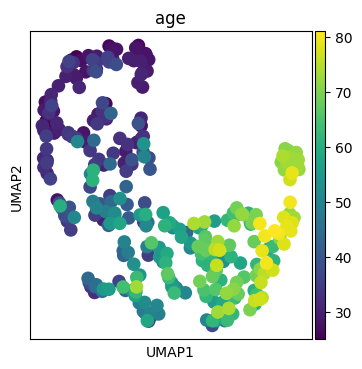

In [68]:
sc.pl.umap(adata, color='age')

## Run details

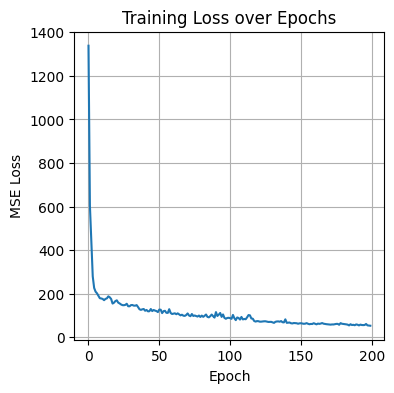

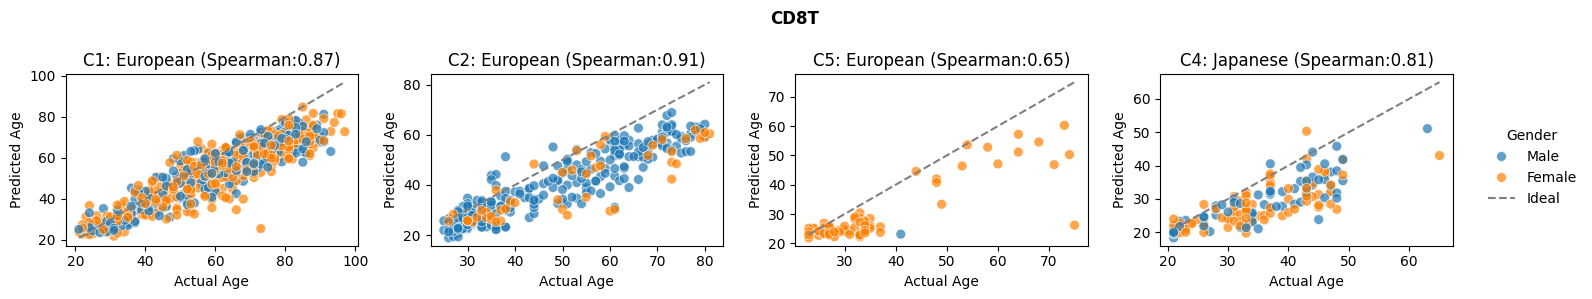

In [69]:
if reg_type == 'NN':
    loss = np.load(f'{temp_dir}/loss.npy')
    plt.plot(loss)
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Training Loss over Epochs')
    plt.grid(True)
    plt.show()
if reg_type == 'NN':
    from ciim.src.clock.helper import evaluate_groupwise_median
    for cell_type in cell_types:
        adata_all = ad.read_h5ad(f"{temp_dir}/{cell_type}_{data_type}_{feature_type}_{reg_type}_adata.h5ad")
        obs = adata_all.obs.copy()
        obs['sex'] = obs['sex'].astype(str)
        obs['donor_age'] = obs['donor_age'].astype(str)
        obs['age'] = obs['age'].astype(float)
        obs['predicted_age'] = obs['predicted_age'].astype(float)
        datasets = obs['dataset'].unique()
        fig, axes = plt.subplots(1, len(datasets), figsize=(4*len(datasets), 3))
        i = 0
        for dataset in datasets:
            ax = axes[i] if len(datasets) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = obs_d.groupby(['donor_age', 'age', 'sex'])['predicted_age'].median().reset_index()
            sns.scatterplot(data=obs_d, x='age', y='predicted_age', s=50, alpha=0.7, ax=ax, palette=palette_genders, hue='sex')
            min_age, max_age = obs_d['age'].min(), obs_d['age'].max()
            ax.plot([min_age, max_age], [min_age, max_age], color='gray', linestyle='--', label='Ideal')

            ax.set_xlabel("Actual Age")
            ax.set_ylabel("Predicted Age")

            spearman = evaluate_groupwise_median(obs_d)['Spearman']
            ax.set_title(f"{surrogate_names[dataset]} (Spearman:{spearman:.2f})")

            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')

        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

#  Compare to wenchao's results

In [42]:
W_train_datasets = ['data1', 'data7_allTPs_jalil'] # we only use these datasets for training for a fair comparision
test_datasets = ['SLE_European', 'data13_Korean']

version = 'comparitive'

In [43]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *W_train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD4T CD8T MONO B NK --datasets_training data1 data7_allTPs_jalil --feature_type gene_expression --data_type bulk --reg_type ridge --version comparitive --temp_dir /Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/ --age_limit 20 --tune_model
{'cell_types': ['CD4T', 'CD8T', 'MONO', 'B', 'NK'], 'datasets_training': ['data1', 'data7_allTPs_jalil'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'comparitive', 'temp_dir': '/Users/jno24/Documents/projs/ongoing/ciim/base_folder/output//temp/', 'age_limit': 20}
building model for cell type: CD4T
(1285, 1019) (1285,)


Best trial: 12. Best value: -2.51154: 100%|██████████| 30/30 [00:00<00:00, 43.88it/s]



 Best alpha: 997.6649, Best CV performance: -2.5115
building model for cell type: CD8T
(1285, 2042) (1285,)


Best trial: 28. Best value: 0.524776: 100%|██████████| 30/30 [00:00<00:00, 30.33it/s]



 Best alpha: 587.5307, Best CV performance: 0.5248
building model for cell type: MONO
(1078, 3416) (1078,)


...


 Best alpha: 986.4360, Best CV performance: -9.3233
building model for cell type: B
(1281, 1587) (1281,)


Best trial: 21. Best value: -0.739119: 100%|██████████| 30/30 [00:01<00:00, 28.84it/s]



 Best alpha: 210.9262, Best CV performance: -0.7391
building model for cell type: NK
(1285, 481) (1285,)


Best trial: 21. Best value: -10.1824: 100%|██████████| 30/30 [00:00<00:00, 91.32it/s]



 Best alpha: 938.7033, Best CV performance: -10.1824


## Get W results on test data

In [44]:
def extract_w_results():
    # - read the results of predictions
    df_store = []
    for dataset in ['C4', 'C5']:
        df = pd.read_csv(f'{base_dir}/clock/wenchao/val_data_majorCT_Wenchao_AC_{dataset}_predicted_age_donor.tsv', sep='\t')
        df['dataset'] = 'data13_Korean' if dataset=='C4' else 'SLE_European'
        df_store.append(df)
    df = pd.concat(df_store, axis=0)
    df['donor_age'] = df['donor_id'].astype(str) + '_' + df['age'].astype(str)
    # - format 
    df.rename(columns={'Prediction': 'predicted_age', 'CT': 'cell_type'}, inplace=True)
    df['sex'] = df['sex'].map({'M': 'Male', 'F': 'Female'})
    # - median prediction
    median_prediction = df.groupby(['cell_type', 'donor_age', 'dataset'])['predicted_age'].median().reset_index()
    median_prediction = df[['cell_type', 'donor_age', 'age', 'sex', 'dataset']].drop_duplicates().merge(median_prediction, on=['cell_type', 'donor_age', 'dataset'], how='left')
    return median_prediction
W_median_prediction = extract_w_results()

## Get our results on test data

In [45]:
predictions_all = get_all_predictions(cell_types, test_datasets, version=version)
predictions_all.head()

,age,predicted_age,sex,donor_age,dataset,cell_type,condition
148,39,27.650226,Female,100439,SLE_European,CD4T,SLE
149,40,13.711211,Female,101440,SLE_European,CD4T,SLE
150,54,26.928179,Female,101554,SLE_European,CD4T,SLE
151,64,39.186462,Female,101964,SLE_European,CD4T,SLE
152,42,8.997432,Female,103942,SLE_European,CD4T,SLE


In [46]:
from ciim.src.clock.helper import evaluate_groupwise_median
test_predictions = predictions_all[(predictions_all['dataset'].isin(test_datasets)) & (predictions_all['condition']=='Healthy')]
test_predictions.head()

,age,predicted_age,sex,donor_age,dataset,cell_type,condition
224,27,6.383235,Male,HC-00227,SLE_European,CD4T,Healthy
225,53,30.540975,Female,HC-00653,SLE_European,CD4T,Healthy
226,48,31.540945,Female,HC-00848,SLE_European,CD4T,Healthy
227,27,-0.679723,Female,HC-00927,SLE_European,CD4T,Healthy
228,35,14.401284,Female,HC-02035,SLE_European,CD4T,Healthy


In [47]:
test_predictions['dataset'].unique()

array(['SLE_European', 'data13_Korean'], dtype=object)

## Calculate the scores

In [48]:
import pandas as pd

all_scores = []

for cell_type in test_predictions['cell_type'].unique():
    for dataset in test_datasets:
        # Your model
        df1 = test_predictions[
            (test_predictions['dataset'] == dataset) & 
            (test_predictions['cell_type'] == cell_type)
        ].copy()
        ss1 = evaluate_groupwise_median(df1)  # returns {'Spearman': ..., 'R2': ...}
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'GRNdrived',
            'Spearman': ss1['Spearman'],
            'R2': ss1['R2']
        })

        # Wenchao's model
        df2 = W_median_prediction[
            (W_median_prediction['dataset'] == dataset) & 
            (W_median_prediction['cell_type'] == cell_type)
        ].copy()
        ss2 = evaluate_groupwise_median(df2)
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'Wenchao',
            'Spearman': ss2['Spearman'],
            'R2': ss2['R2']
        })

# Convert to DataFrame
score_df = pd.DataFrame(all_scores)


## Plot

In [49]:
palette_models = {
    'Wenchao': colors_blind[1], 
    'GRNdrived': colors_blind[0]
}

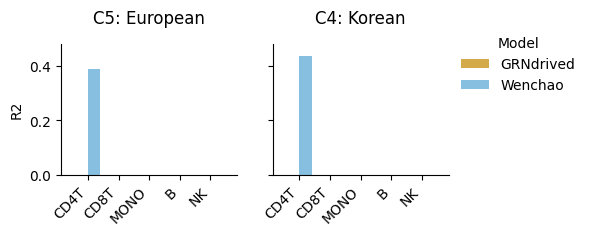

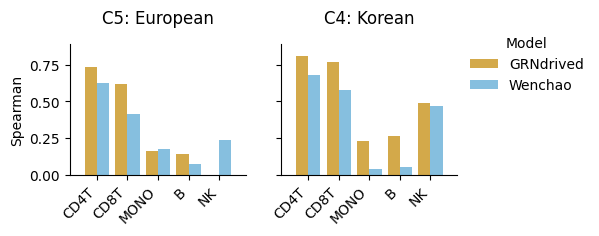

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clip R2 to [0, 1]
score_df['R2'] = score_df['R2'].clip(0, 1)

# Sort datasets for consistent layout
datasets = score_df['dataset'].unique()
n_datasets = len(datasets)

# Plot each metric in a separate figure
for metric in ['R2', 'Spearman']:
    fig, axes = plt.subplots(1, n_datasets, figsize=(2.5 * n_datasets, 1.7), sharey=True)

    if n_datasets == 1:
        axes = [axes]  # Ensure iterable if only one axis

    for ax, dataset in zip(axes, datasets):
        df_plot = score_df[score_df['dataset'] == dataset]

        sns.barplot(
            data=df_plot,
            x='cell_type',
            y=metric,
            hue='model',
            ax=ax,
            alpha=0.8,
            palette=palette_models,
        )   

        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.margins(x=0.1, y=0.1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.get_legend().remove()
        ax.set_title(f'{surrogate_names[dataset]}', pad=15)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Model', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # fig.tight_layout()
    plt.savefig(f'{plots_dir}/clock_comparison_{metric}.png', bbox_inches='tight', dpi=300, transparent=True)


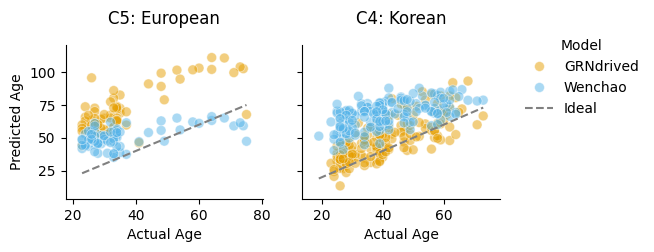

In [51]:
W_median_prediction['model'] = 'Wenchao'
test_predictions['model'] = 'GRNdrived'

obs = pd.concat([test_predictions, W_median_prediction], axis=0)
datasets = obs['dataset'].unique()

for cell_type in ['CD8T']:
    fig, axes = plt.subplots(1, len(datasets), figsize=(2.8*len(datasets), 2), sharey=True)
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

        plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax, hue='model', palette=palette_models)
        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .5), frameon=False, title='Model')
    plt.savefig(f'{plots_dir}/clock_comparison_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)
    
    # plt.suptitle(cell_type, fontsize=12, weight='bold')
    # plt.tight_layout()

# Performance on train data

In [89]:
obs = get_all_predictions(cell_types, train_datasets)
obs['dataset'] = pd.Categorical(obs['dataset'],
                                categories=datasets_all,
                                ordered=True)

### Line plot

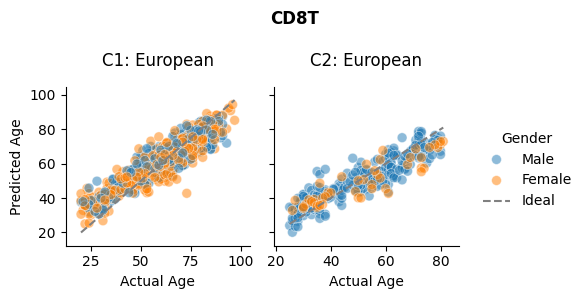

In [54]:
from ciim.src.clock.helper import evaluate_groupwise_median

obs['sex'] = obs['sex'].astype('str')

datasets = datasets_all

datasets_healthy = [d for d in  datasets if d in obs[(obs['condition'] == 'Healthy')]['dataset'].unique()]

if True:
    for cell_type in ['CD8T']:
        fig, axes = plt.subplots(1, len(datasets_healthy), figsize=(3*len(datasets_healthy), 3), sharey=True)
        i = 0
        for dataset in datasets_healthy:
            ax = axes[i] if len(datasets_healthy) > 1 else axes
            obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()
            obs_d = obs_d.groupby(['donor_age', 'age', 'sex'])['predicted_age'].median().reset_index()
            plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax, palette=palette_genders)
            
            ax.spines[['top', 'right']].set_visible(False)
            i+=1
            ax.get_legend().remove()
        ax.legend(loc=(1.1, .2), frameon=False, title='Gender')
        
        plt.suptitle(cell_type, fontsize=12, weight='bold')
        plt.tight_layout()

### Ridge

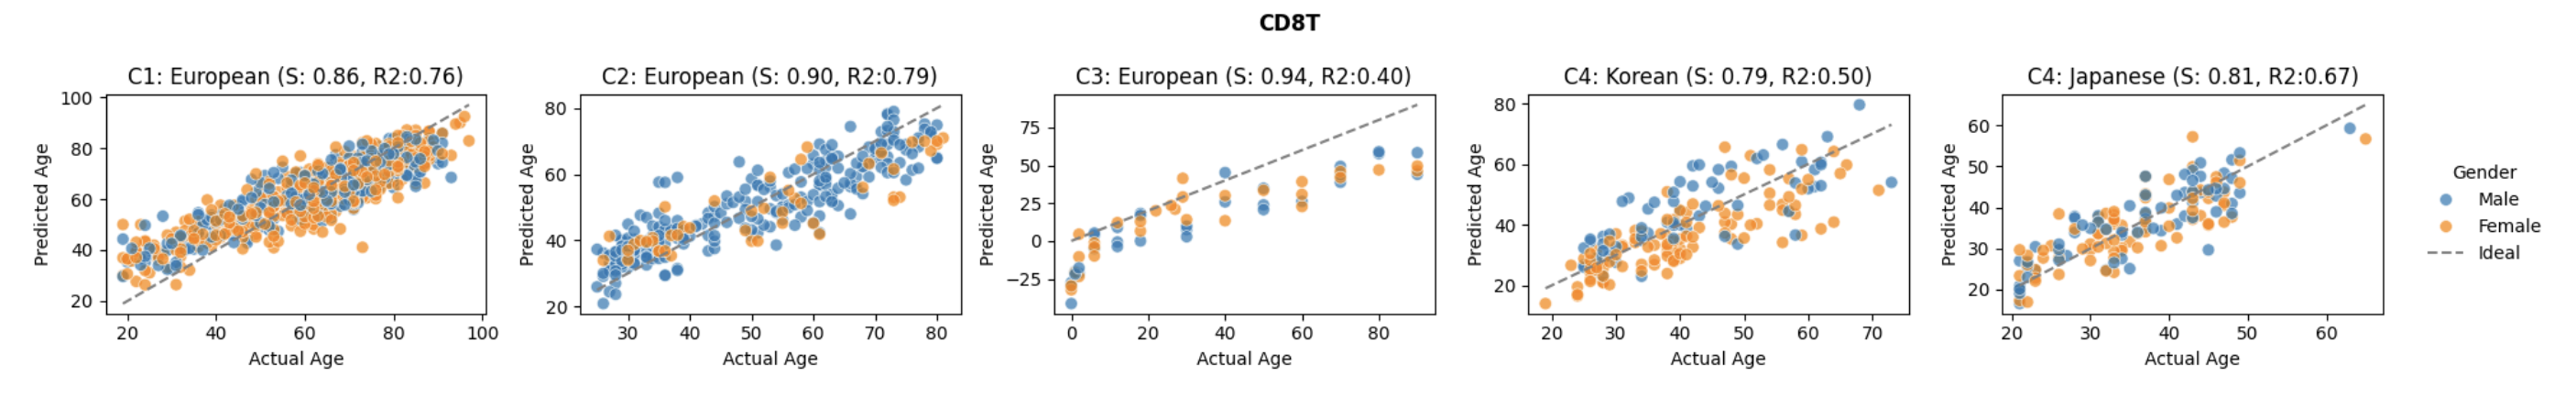

#### ridge

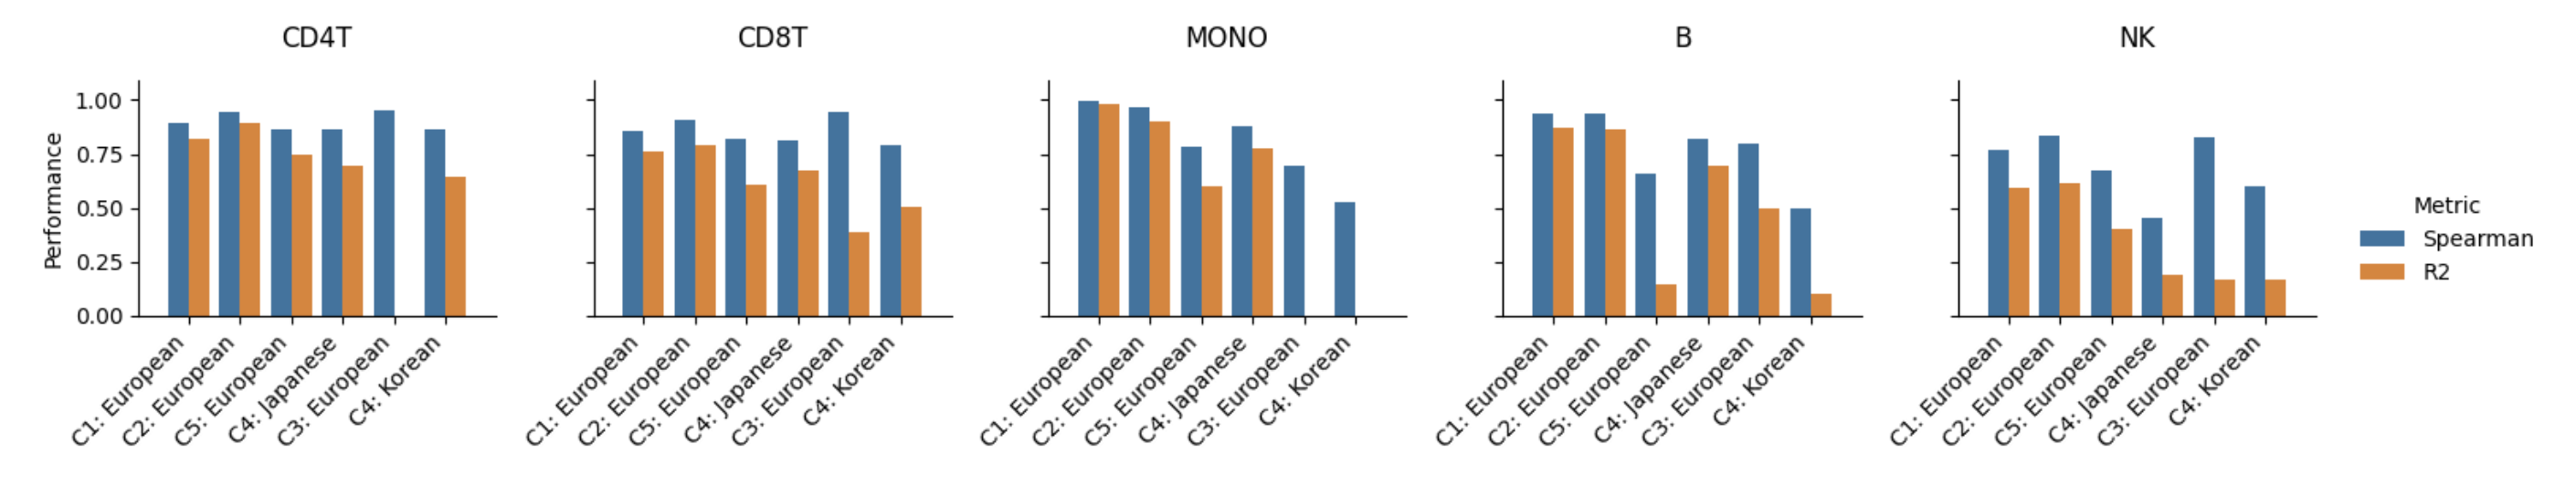

# Performance on disease

In [128]:
obs = get_all_predictions(cell_types, datasets_disease)

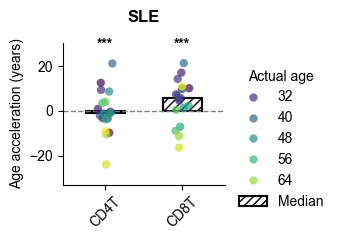

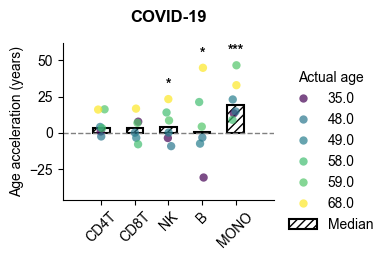

In [134]:
from ciim.src.clock.plots import wrapper_age_acceleration_disease, wrapper_age_acceleration_disease

# Call the function
wrapper_age_acceleration_disease(obs[obs['cell_type'].isin(['CD8T', 'CD4T'])], disease_dataset='SLE_European', figsize=(3.5, 2.5))
plt.savefig(f'{plots_dir}/clock_SLE.png', bbox_inches='tight', dpi=300, transparent=True)
wrapper_age_acceleration_disease(obs, disease_dataset='Covid_50MHH')

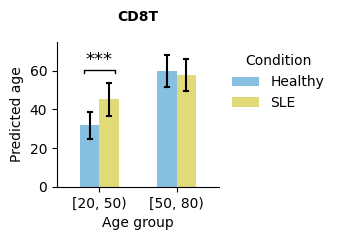

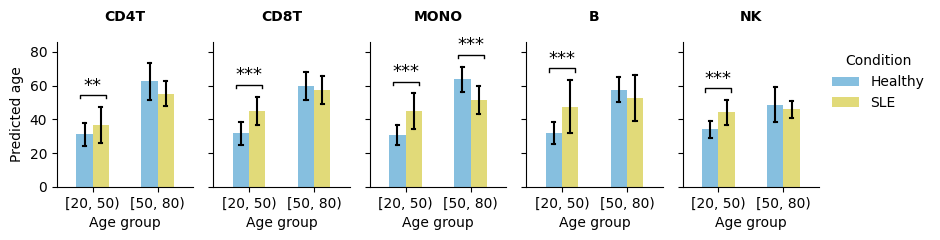

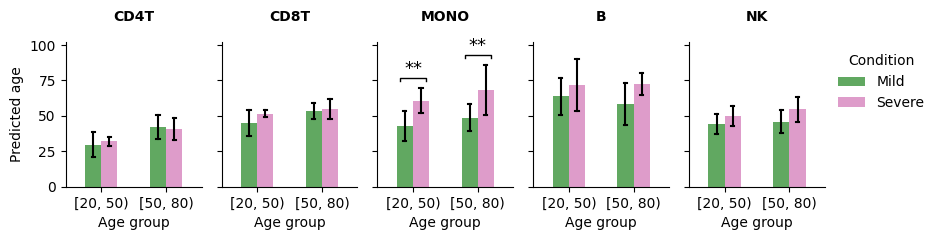

In [125]:
from ciim.src.clock.plots import wrapper_plot_age_acceleration_disease_bins

# Example usage (make sure n_cell_types, cell_types, and surrogate_names are defined)
wrapper_plot_age_acceleration_disease_bins(obs[obs['cell_type']=='CD8T'], disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins_cd8t.png', bbox_inches='tight', dpi=300, transparent=True)

wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins.png', bbox_inches='tight', dpi=300, transparent=True)
wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='Covid_50MHH')

# Drug perturbation

In [116]:
obs_cxcl9 =  get_all_predictions(cell_types, ['CXCL9'])
obs_cxcl9['condition'].unique()

array(['0 h Unstimulated', '24 h LPS', '24 h LPS + metformin',
       '24 h LPS + metformin + ruxolitinib', '24 h LPS + ruxolitinib',
       '24 h RPMI', '24 h RPMI + metformin',
       '24 h RPMI + metformin + ruxolitinib', '24 h RPMI + ruxolitinib',
       '24 h rhCXCL9', '24 h rhIFN-γ'], dtype=object)

In [117]:
pretty_names = {
    '24 h LPS': 'LPS',
    '24 h LPS + metformin': 'Met.',
    # '24 h LPS + metformin + ruxolitinib': 'LPS / Met+Rux', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'LPS+Rux.',
    '24 h RPMI': 'RPMI',
    '24 h RPMI + metformin': 'RPMI+Met',
    # '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met+Rux',
    '24 h RPMI + ruxolitinib': 'RPMI+Rux',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}

experiments = [
                # ('24 h RPMI', '24 h rhCXCL9'),
                ('24 h RPMI', '24 h LPS'),
                # ('24 h RPMI', '24 h rhIFN-γ'),
                ('24 h RPMI', '24 h RPMI + metformin'),
                ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                ('24 h LPS', '24 h LPS + metformin'),
                ('24 h LPS', '24 h LPS + ruxolitinib'),
                # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                ]
n_exp = len(experiments)

In [118]:
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = [] 
slopes = []

def test_paired(df_sub):
    df_pivot = df_sub.pivot(index='donor_age', columns='condition', values='predicted_age').dropna()
    t_stat, p_value = stats.ttest_rel(df_pivot[treatment], df_pivot[ctr])
    slope = (df_pivot[treatment] - df_pivot[ctr]).mean()
    return p_value, slope

def test_mixed_effect(df_sub):
    import statsmodels.formula.api as smf
    df_sub['condition'] = pd.Categorical(df_sub['condition'], categories=[ctr, treatment])
    # Fit the mixed effects model
    model = smf.mixedlm("predicted_age ~ condition", df_sub, groups=df_sub["donor_age"])
    result = model.fit()
    # # Summary of the model
    # print(result.summary())
    # Extract p-value and fixed effect estimate for treatment
    p_value = result.pvalues[f"condition[T.{treatment}]"]
    slope = result.params[f"condition[T.{treatment}]"]
    return p_value, slope
for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_age', 'condition', 'predicted_age']].copy()

    for i, (ctr, treatment) in enumerate(experiments):
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        if df_sub.shape[0] < 2:
            continue  # Skip if not enough data
        
        if 'bulk' in data_type:
            p_value, slope = test_paired(df_sub)

        elif data_type == 'metacell':
            df_sub = df_sub.groupby(['donor_age', 'condition'])['predicted_age'].median().reset_index()
            p_value, slope = test_paired(df_sub)
            # p_value, slope = test_mixed_effect(df_sub)
        else:
            raise ValueError("Unsupported data type")
        raw_pvals.append(p_value)
        slopes.append(slope)
        test_labels.append((cell_type, ctr, treatment))

# Apply FDR correction
rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')

# Optionally: map corrected p-values back to plotting
pval_map = {
    (cell_type, ctr, treatment): (pval, slope)
    for (cell_type, ctr, treatment), pval, slope in zip(test_labels, corrected_pvals, slopes)
}

# Redraw plots with adjusted p-values
unique_donors = obs_cxcl9['donor_age'].unique()
donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))  # or use 'tab20', 'Set3', etc.


### All sig and not sig ones

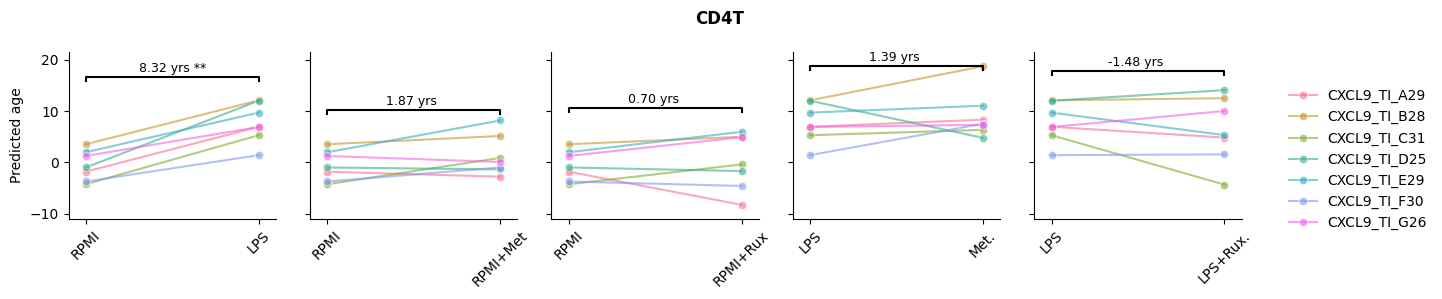

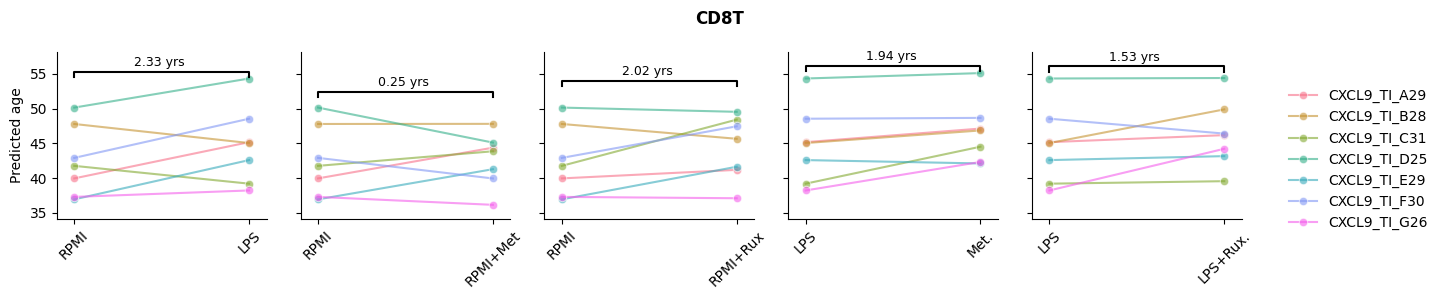

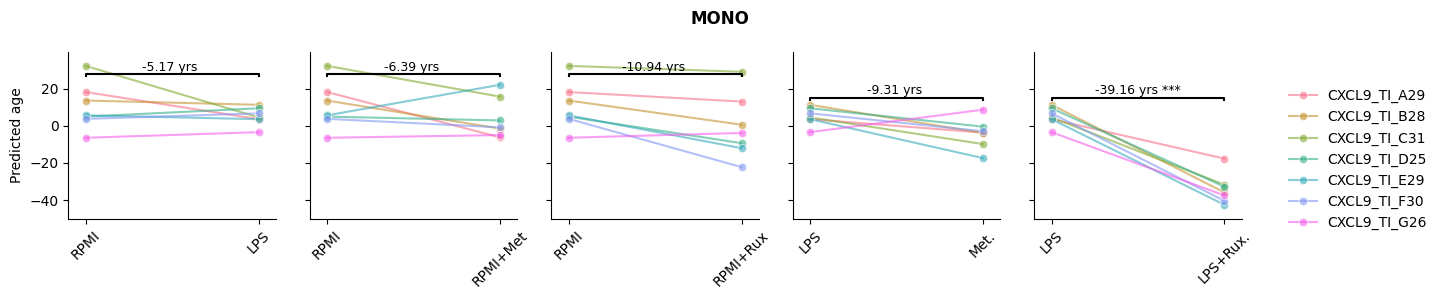

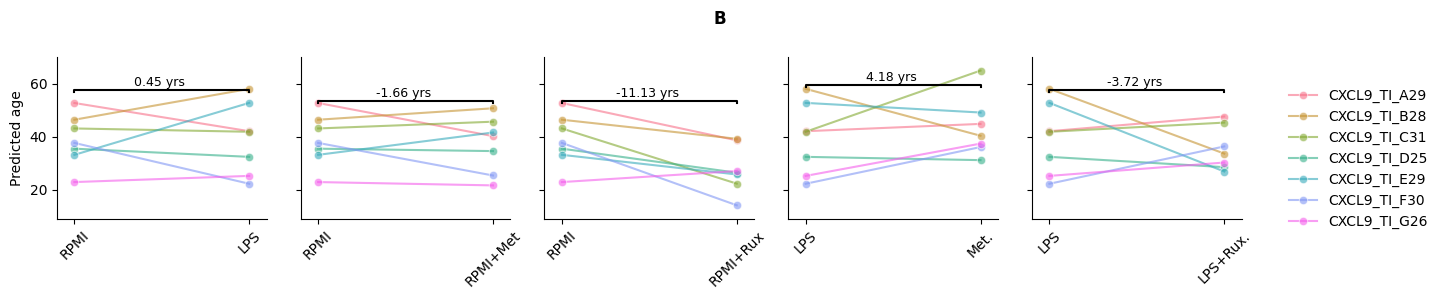

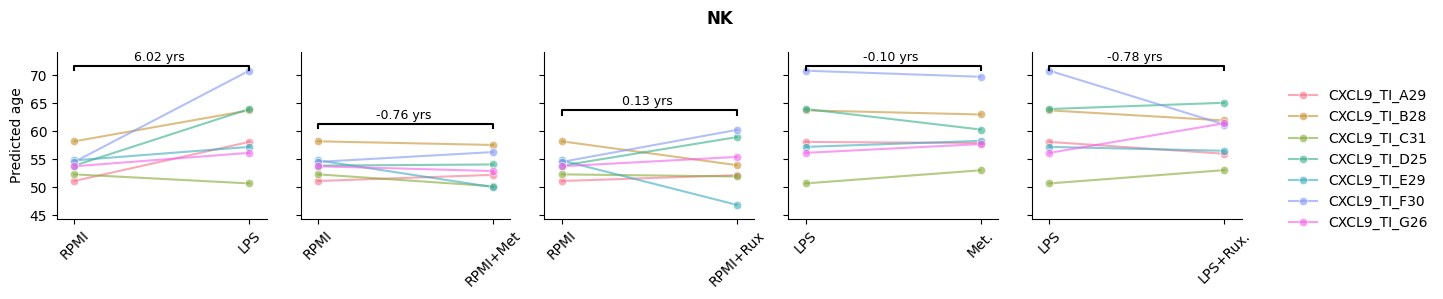

In [119]:
alpha = 0.05  # significance threshold

for cell_type in obs_cxcl9['cell_type'].unique():
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_age', 'condition', 'predicted_age']].copy()
    fig, axes = plt.subplots(1, n_exp, figsize=(2.5 * n_exp + 2, 3), sharey=True)

    if n_exp == 1:
        axes = [axes]

    for i, (ctr, treatment) in enumerate(experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_age', columns='condition', values='predicted_age')
        unique_donors = df_pivot.index.unique()
        donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))

        available_conditions = [cond for cond in [ctr, treatment] if cond in df_pivot.columns]
        if len(available_conditions) < 2:
            continue  # Skip if not both conditions are present

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_age',
            value_vars=available_conditions,
            var_name='condition',
            value_name='predicted_age'
        )

        df_plot['condition'] = df_plot['condition'].apply(lambda name: pretty_names.get(name, name))
        sns.lineplot(
            data=df_plot, x='condition', y='predicted_age',
            hue='donor_age', marker='o', alpha=0.6, ax=ax,
            legend=True, palette=donor_palette
        )

        # Bracket annotation
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        
        xticks = list(ax.get_xticks())
        x1, x2 = xticks[0], xticks[1]

        group_stats = df_plot.groupby('condition')['predicted_age'].agg(['mean', 'std'])
        cond1, cond2 = df_plot['condition'].unique()
        y1 = group_stats.loc[cond1, 'mean'] + group_stats.loc[cond1, 'std']
        y2 = group_stats.loc[cond2, 'mean'] + group_stats.loc[cond2, 'std']
        y_bracket = max(y1, y2) + 5

        h = 0.8  # height of bracket
        ax.plot([x1, x1, x2, x2], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
                lw=1.5, c='black')
        
        ax.text((x1 + x2) / 2, y_bracket + 0.4, f"{slope:.2f} yrs {star}",
                ha='center', va='bottom', fontsize=9)

        ax.set_title("")  # No text in title
        ax.set_ylabel("Predicted age")
        ax.set_xlabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.1)
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc=(1.2, -.1), frameon=False)
    plt.suptitle(cell_type, fontsize=12, weight='bold')
    plt.tight_layout()
    plt.show()

### Only sig ones

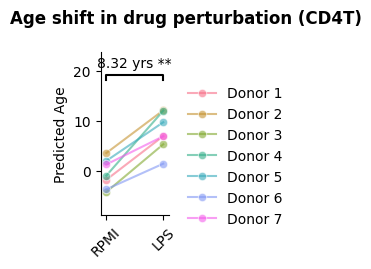

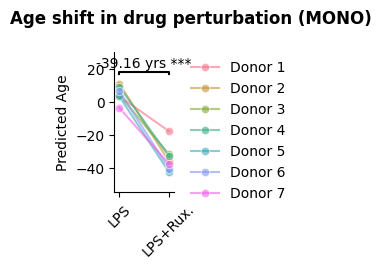

In [121]:
alpha = 0.05  # significance threshold

for cell_type in cell_types:
    obs_t = obs_cxcl9[obs_cxcl9['cell_type'] == cell_type].copy()
    df_all = obs_t[['donor_age', 'condition', 'predicted_age']].copy()

    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < alpha
    ]
    if not significant_experiments:
        continue

    fig, axes = plt.subplots(1, len(significant_experiments), figsize=(2 * len(significant_experiments) + 1, 2.7), sharey=True)
    if len(significant_experiments) == 1:
        axes = [axes]

    for i, (ctr, treatment) in enumerate(significant_experiments):
        ax = axes[i]
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        df_pivot = df_sub.pivot_table(index='donor_age', columns='condition', values='predicted_age')
        df_pivot['donor_age'] = ['Donor ' + str(i+1) for i, d in enumerate(df_pivot.index)]
        df_pivot.set_index('donor_age', inplace=True)
        df_pivot = df_pivot.dropna(subset=[ctr, treatment], how='any')

        unique_donors = df_pivot.index.unique()
        donor_palette = dict(zip(unique_donors, sns.color_palette("husl", len(unique_donors))))

        df_plot = df_pivot.reset_index().melt(
            id_vars='donor_age', 
            value_vars=[ctr, treatment], 
            var_name='condition', 
            value_name='predicted_age'
        )
        df_plot['condition'] = df_plot['condition'].map(pretty_names)

        sns.lineplot(
            data=df_plot,
            x='condition', y='predicted_age',
            hue='donor_age', marker='o', alpha=0.6,
            ax=ax, palette=donor_palette, legend=True
        )

        # Get p-value and slope
        pval, slope = pval_map.get((cell_type, ctr, treatment), (1.0, 0))
        star = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''

        # Draw significance bracket
        y_max = df_plot['predicted_age'].max()
        h = 1  # height of bracket
        y_bracket = y_max + 7

        ax.plot([0, 0, 1, 1], [y_bracket - h, y_bracket, y_bracket, y_bracket - h],
                lw=1.5, c='black')
        ax.text(0.5, y_bracket + 1, f"{slope:.2f} yrs {star}", ha='center', va='bottom', fontsize=10)

        ax.set_title("")  # No text in title
        ax.set_xlabel("")
        ax.set_ylabel("Predicted Age")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
        ax.margins(x=0.1, y=0.2)
        ax.get_legend().remove()
        ax.spines[['top', 'right']].set_visible(False)

    ax.legend(loc=(1.2, -.1), frameon=False)
    fig.suptitle(f'Age shift in drug perturbation ({cell_type})', fontsize=12, weight='bold')
    fig.tight_layout()
    # plt.show()